## Imports and settings

Load libraries, set reproducibility settings, and define the experimental configuration. The experiment is designed as a controlled proof-of-concept. All random number generators are seeded to ensure reproducible results, and key parameters such as sample size, subgroup prevalence, RMST truncation horizon, Monte Carlo iterations, and optimization settings are specified in a single configuration object.

In [1]:
# Standard library
import random
from dataclasses import dataclass

# Scientific computing
import numpy as np
import pandas as pd

# Survival analysis
from lifelines import KaplanMeierFitter

# Visualization
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# ------------------------------------------------------------------
# Experiment configuration
# ------------------------------------------------------------------

@dataclass
class ExperimentConfig:
    n_patients: int = 200
    treatment_ratio: float = 0.50
    subgroup_prevalence: float = 0.40

    # RMST settings
    tau: float = 12.0

    # Monte Carlo settings
    n_mc: int = 5000

    # Optimization settings
    max_iter: int = 5000

config = ExperimentConfig()

# ------------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------------

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# ------------------------------------------------------------------
# Summary
# ------------------------------------------------------------------

print("Environment initialized")
print(config)

Environment initialized
ExperimentConfig(n_patients=200, treatment_ratio=0.5, subgroup_prevalence=0.4, tau=12.0, n_mc=5000, max_iter=5000)


## Simulate Synthetic Reconstructed IPD

We simulate a simple two-arm survival dataset with treatment assignment, event times, censoring, and a hidden binary subgroup label.

The hidden subgroup label is only used to generate realistic survival heterogeneity. Later, we will pretend this label is unknown and only use aggregate constraints to reconstruct feasible assignments.

In [2]:
def simulate_trial(config: ExperimentConfig, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    n = config.n_patients

    # Treatment assignment
    treatment = rng.binomial(1, config.treatment_ratio, size=n)

    # Hidden subgroup label
    z_true = rng.binomial(1, config.subgroup_prevalence, size=n)

    # Baseline hazard structure
    base_hazard = 0.10

    # Treatment lowers hazard
    treatment_effect = 0.70

    # Subgroup-positive patients have better prognosis
    subgroup_effect = 0.75

    # Extra treatment benefit for subgroup-positive patients
    interaction_effect = 0.70

    hazard = (
        base_hazard
        * (treatment_effect ** treatment)
        * (subgroup_effect ** z_true)
        * (interaction_effect ** (treatment * z_true))
    )

    # Event times from exponential survival model
    event_time = rng.exponential(scale=1 / hazard)

    # Random censoring
    censor_time = rng.uniform(6, 24, size=n)

    time = np.minimum(event_time, censor_time)
    event = (event_time <= censor_time).astype(int)

    df = pd.DataFrame(
        {
            "id": np.arange(n),
            "time": time,
            "event": event,
            "treatment": treatment,
            "z_true": z_true,
        }
    )

    return df


df = simulate_trial(config)

df.head()

,id,time,event,treatment,z_true
0,0,1.920755,1,1,1
1,1,4.551702,1,0,1
2,2,11.556158,1,1,0
3,3,3.782580,1,1,0
4,4,4.294038,1,0,0


In [3]:
df.describe()

,id,time,event,treatment,z_true
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,99.500000,8.781606,0.605000,0.480000,0.395000
std,57.879185,6.183317,0.490077,0.500854,0.490077
min,0.000000,0.194905,0.000000,0.000000,0.000000
25%,49.750000,3.857385,0.000000,0.000000,0.000000
50%,99.500000,7.930588,1.000000,0.000000,0.000000
75%,149.250000,11.769844,1.000000,1.000000,1.000000
max,199.000000,23.723692,1.000000,1.000000,1.000000


In [4]:
pd.crosstab(df["treatment"], df["z_true"], margins=True)

z_true,0,1,All
treatment,,,
0,60,44,104
1,61,35,96
All,121,79,200


## Hide True Subgroup Labels

In a real reconstruction setting, subgroup labels are unknown.

To mimic this setting, the true subgroup assignments are removed from the observed dataset and retained only for later evaluation.

The reconstruction algorithms will only have access to survival outcomes and treatment assignments, together with aggregate subgroup information.

In [5]:
# Save truth for evaluation
z_true = df["z_true"].copy()

# Observed reconstructed dataset
observed_df = df.drop(columns=["z_true"]).copy()

observed_df.head()

,id,time,event,treatment
0,0,1.920755,1,1
1,1,4.551702,1,0
2,2,11.556158,1,1
3,3,3.782580,1,1
4,4,4.294038,1,0


In [6]:
# "published information"
print(f"Total subgroup-positive patients: {z_true.sum()}")

print(
    pd.crosstab(
        df["treatment"],
        z_true,
        margins=True
    )
)

Total subgroup-positive patients: 79
z_true       0   1  All
treatment              
0           60  44  104
1           61  35   96
All        121  79  200


## Define Feasible Assignment Constraints

We assume that published evidence reports subgroup counts but does not reveal individual subgroup assignments.

For this proof-of-concept experiment, feasible assignments must satisfy:

- Total subgroup-positive count.
- Treatment-arm-specific subgroup counts.

Any assignment satisfying these constraints belongs to the feasible assignment space.

Later experiments can incorporate additional constraints such as subgroup survival summaries, RMST values, or hazard ratios.

In [7]:
K = int(z_true.sum())

K1 = int(
    z_true[df["treatment"] == 1].sum()
)

K0 = int(
    z_true[df["treatment"] == 0].sum()
)

print("Total subgroup-positive:", K)
print("Treatment arm subgroup-positive:", K1)
print("Control arm subgroup-positive:", K0)

Total subgroup-positive: 79
Treatment arm subgroup-positive: 35
Control arm subgroup-positive: 44


In [8]:
def generate_feasible_assignment(
    treatment,
    K1,
    K0,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    z = np.zeros(len(treatment), dtype=int)

    treated_idx = np.where(treatment == 1)[0]
    control_idx = np.where(treatment == 0)[0]

    treated_positive = rng.choice(
        treated_idx,
        size=K1,
        replace=False
    )

    control_positive = rng.choice(
        control_idx,
        size=K0,
        replace=False
    )

    z[treated_positive] = 1
    z[control_positive] = 1

    return z

In [9]:
z_test = generate_feasible_assignment(
    observed_df["treatment"].values,
    K1,
    K0
)

pd.crosstab(
    observed_df["treatment"],
    z_test,
    margins=True
)

col_0,0,1,All
treatment,,,
0,60,44,104
1,61,35,96
All,121,79,200


## RMST Estimator

For each feasible subgroup assignment, we estimate the treatment effect using the restricted mean survival time (RMST).

RMST is defined as the area under the survival curve up to a fixed horizon. Here we use `tau = 12`.

For a given subgroup assignment, the treatment effect is:

`RMST(treated, subgroup-positive) - RMST(control, subgroup-positive)`

In [10]:
def estimate_rmst(time, event, tau):
    kmf = KaplanMeierFitter()
    kmf.fit(time, event_observed=event)

    surv = kmf.survival_function_.reset_index()
    surv.columns = ["time", "survival"]

    times = np.concatenate([[0], surv["time"].values])
    survival = np.concatenate([[1.0], surv["survival"].values])

    times = np.clip(times, 0, tau)

    keep = times <= tau
    times = times[keep]
    survival = survival[keep]

    if times[-1] < tau:
        times = np.append(times, tau)
        survival = np.append(survival, survival[-1])

    rmst = np.sum(np.diff(times) * survival[:-1])
    return rmst

In [11]:
def rmst_treatment_effect(df, z, tau):
    df_eval = df.copy()
    df_eval["z"] = z

    treated = df_eval[(df_eval["treatment"] == 1) & (df_eval["z"] == 1)]
    control = df_eval[(df_eval["treatment"] == 0) & (df_eval["z"] == 1)]

    rmst_treated = estimate_rmst(
        treated["time"],
        treated["event"],
        tau
    )

    rmst_control = estimate_rmst(
        control["time"],
        control["event"],
        tau
    )

    return rmst_treated - rmst_control

In [12]:
true_effect = rmst_treatment_effect(
    observed_df,
    z_true.values,
    config.tau
)

print(f"True subgroup RMST treatment effect: {true_effect:.3f}")

True subgroup RMST treatment effect: 1.290


In [13]:
random_effect = rmst_treatment_effect(
    observed_df,
    z_test,
    config.tau
)

print(f"Random feasible assignment RMST effect: {random_effect:.3f}")

Random feasible assignment RMST effect: 0.812


## Monte Carlo Feasible Assignment Search

We now sample many feasible subgroup assignments satisfying the aggregate count constraints.

For each feasible assignment, we compute the subgroup-specific RMST treatment effect.

This gives an empirical distribution of treatment effects induced by reconstruction uncertainty.

In [14]:
rng = np.random.default_rng(SEED)

mc_effects = []

for _ in range(config.n_mc):
    z_mc = generate_feasible_assignment(
        observed_df["treatment"].values,
        K1,
        K0,
        rng=rng
    )

    effect = rmst_treatment_effect(
        observed_df,
        z_mc,
        config.tau
    )

    mc_effects.append(effect)

mc_effects = np.array(mc_effects)

mc_summary = pd.Series(mc_effects).describe(
    percentiles=[0.25, 0.5, 0.75]
)

mc_summary

count    5000.000000
mean        1.060419
std         0.761053
min        -1.839466
25%         0.577854
50%         1.058822
75%         1.568958
max         3.664446
dtype: float64

In [15]:
print(f"Monte Carlo min: {mc_effects.min():.3f}")
print(f"Monte Carlo max: {mc_effects.max():.3f}")
print(f"True-label effect: {true_effect:.3f}")

Monte Carlo min: -1.839
Monte Carlo max: 3.664
True-label effect: 1.290


In [16]:
mc_results = pd.Series(mc_effects)

summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Q1",
        "Median",
        "Mean",
        "Q3",
        "Maximum",
        "True Effect"
    ],
    "Value": [
        mc_results.min(),
        mc_results.quantile(0.25),
        mc_results.quantile(0.50),
        mc_results.mean(),
        mc_results.quantile(0.75),
        mc_results.max(),
        true_effect
    ]
})

summary

,Statistic,Value
0,Minimum,-1.839466
1,Q1,0.577854
2,Median,1.058822
3,Mean,1.060419
4,Q3,1.568958
5,Maximum,3.664446
6,True Effect,1.290337


In [17]:
print(
    f"Percentile of true effect: "
    f"{100 * (mc_effects < true_effect).mean():.1f}%"
)

Percentile of true effect: 61.7%


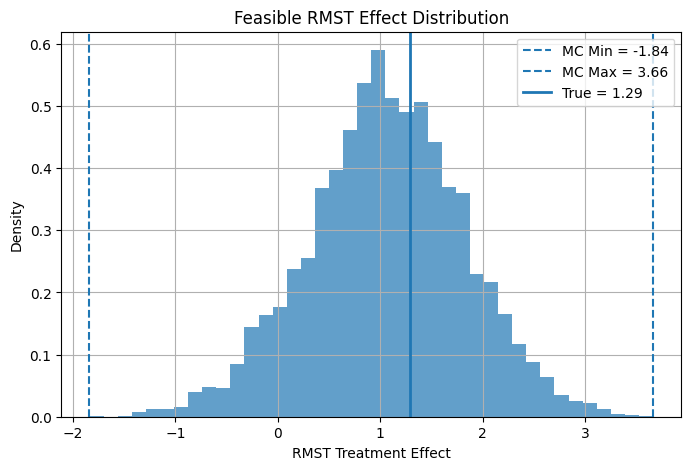

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    mc_effects,
    bins=40,
    density=True,
    alpha=0.7
)

plt.axvline(
    mc_effects.min(),
    linestyle="--",
    label=f"MC Min = {mc_effects.min():.2f}"
)

plt.axvline(
    mc_effects.max(),
    linestyle="--",
    label=f"MC Max = {mc_effects.max():.2f}"
)

plt.axvline(
    true_effect,
    linewidth=2,
    label=f"True = {true_effect:.2f}"
)

plt.xlabel("RMST Treatment Effect")
plt.ylabel("Density")
plt.title("Feasible RMST Effect Distribution")
plt.legend()

plt.show()

## Simulated Tempering Search

Monte Carlo sampling characterizes typical feasible assignments, but it may miss rare boundary assignments.

Simulated tempering searches the feasible assignment space across multiple temperatures. High temperatures encourage broad exploration, while low temperatures concentrate the search near assignments with more extreme RMST effects.

We run the algorithm twice:

1. Maximization: search for the largest feasible RMST effect.
2. Minimization: search for the smallest feasible RMST effect.

In [19]:
def propose_label_swap(z, treatment, rng):
    """
    Propose a feasible label swap.

    If arm-specific subgroup counts are fixed, swap labels within one randomly
    selected treatment arm. This preserves K0 and K1 automatically.
    """
    z_new = z.copy()

    arm = rng.choice([0, 1])
    arm_idx = np.where(treatment == arm)[0]

    pos_idx = arm_idx[z[arm_idx] == 1]
    neg_idx = arm_idx[z[arm_idx] == 0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        return z_new

    i = rng.choice(pos_idx)
    j = rng.choice(neg_idx)

    z_new[i], z_new[j] = z_new[j], z_new[i]

    return z_new

In [20]:
def simulated_tempering_search(
    df,
    initial_z,
    tau,
    temperatures,
    n_iter=5000,
    mode="max",
    seed=SEED,
):
    """
    Simulated tempering search over feasible subgroup assignments.

    Parameters
    ----------
    mode : {"max", "min"}
        If "max", search for the largest RMST effect.
        If "min", search for the smallest RMST effect.
    """
    rng = np.random.default_rng(seed)

    treatment = df["treatment"].values

    z_current = initial_z.copy()
    effect_current = rmst_treatment_effect(df, z_current, tau)

    if mode == "max":
        score_current = effect_current
    elif mode == "min":
        score_current = -effect_current
    else:
        raise ValueError("mode must be 'max' or 'min'")

    best_z = z_current.copy()
    best_effect = effect_current
    best_score = score_current

    temp_idx = len(temperatures) // 2
    T = temperatures[temp_idx]

    trace = []

    for it in range(n_iter):
        z_prop = propose_label_swap(
            z_current,
            treatment,
            rng
        )

        effect_prop = rmst_treatment_effect(df, z_prop, tau)

        if mode == "max":
            score_prop = effect_prop
        else:
            score_prop = -effect_prop

        delta = score_prop - score_current

        if delta >= 0:
            accept = True
        else:
            accept_prob = np.exp(delta / T)
            accept = rng.uniform() < accept_prob

        if accept:
            z_current = z_prop
            effect_current = effect_prop
            score_current = score_prop

        if score_current > best_score:
            best_z = z_current.copy()
            best_effect = effect_current
            best_score = score_current

        # Temperature move
        if rng.uniform() < 0.10:
            proposal_shift = rng.choice([-1, 1])
            new_temp_idx = temp_idx + proposal_shift

            if 0 <= new_temp_idx < len(temperatures):
                temp_idx = new_temp_idx
                T = temperatures[temp_idx]

        trace.append(
            {
                "iteration": it,
                "effect": effect_current,
                "score": score_current,
                "best_effect": best_effect,
                "temperature": T,
                "accepted": accept,
            }
        )

    trace_df = pd.DataFrame(trace)

    return {
        "best_z": best_z,
        "best_effect": best_effect,
        "trace": trace_df,
    }

In [21]:
temperatures = np.array([0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00])

z_init = generate_feasible_assignment(
    observed_df["treatment"].values,
    K1,
    K0,
    rng=np.random.default_rng(SEED)
)

st_max = simulated_tempering_search(
    observed_df,
    initial_z=z_init,
    tau=config.tau,
    temperatures=temperatures,
    n_iter=config.max_iter,
    mode="max",
    seed=SEED
)

st_min = simulated_tempering_search(
    observed_df,
    initial_z=z_init,
    tau=config.tau,
    temperatures=temperatures,
    n_iter=config.max_iter,
    mode="min",
    seed=SEED + 1
)

print(f"ST minimum: {st_min['best_effect']:.3f}")
print(f"ST maximum: {st_max['best_effect']:.3f}")
print(f"MC minimum: {mc_effects.min():.3f}")
print(f"MC maximum: {mc_effects.max():.3f}")

ST minimum: -6.761
ST maximum: 6.774
MC minimum: -1.839
MC maximum: 3.664


In [22]:
comparison = pd.DataFrame({
    "Method": ["Monte Carlo", "Simulated Tempering"],
    "Minimum": [mc_effects.min(), st_min["best_effect"]],
    "Maximum": [mc_effects.max(), st_max["best_effect"]],
    "Width": [
        mc_effects.max() - mc_effects.min(),
        st_max["best_effect"] - st_min["best_effect"],
    ],
})

comparison

,Method,Minimum,Maximum,Width
0,Monte Carlo,-1.839466,3.664446,5.503913
1,Simulated Tempering,-6.760887,6.774433,13.535321


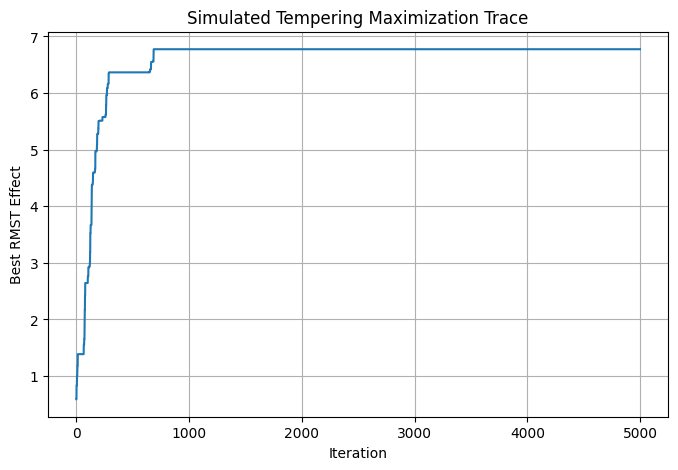

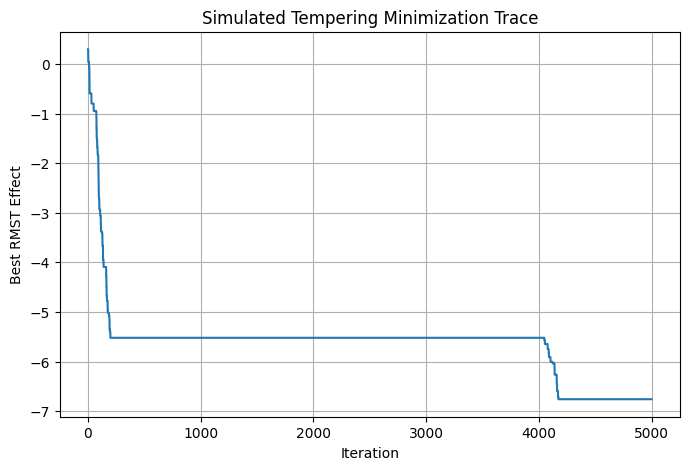

In [23]:
plt.figure(figsize=(8,5))
plt.plot(st_max["trace"]["iteration"], st_max["trace"]["best_effect"])
plt.xlabel("Iteration")
plt.ylabel("Best RMST Effect")
plt.title("Simulated Tempering Maximization Trace")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(st_min["trace"]["iteration"], st_min["trace"]["best_effect"])
plt.xlabel("Iteration")
plt.ylabel("Best RMST Effect")
plt.title("Simulated Tempering Minimization Trace")
plt.show()

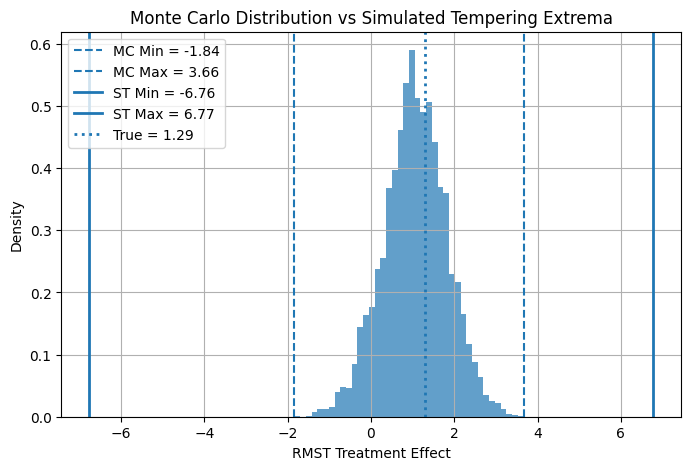

In [24]:
plt.figure(figsize=(8,5))

plt.hist(mc_effects, bins=40, density=True, alpha=0.7)

plt.axvline(mc_effects.min(), linestyle="--", label=f"MC Min = {mc_effects.min():.2f}")
plt.axvline(mc_effects.max(), linestyle="--", label=f"MC Max = {mc_effects.max():.2f}")

plt.axvline(st_min["best_effect"], linewidth=2, label=f"ST Min = {st_min['best_effect']:.2f}")
plt.axvline(st_max["best_effect"], linewidth=2, label=f"ST Max = {st_max['best_effect']:.2f}")

plt.axvline(true_effect, linestyle=":", linewidth=2, label=f"True = {true_effect:.2f}")

plt.xlabel("RMST Treatment Effect")
plt.ylabel("Density")
plt.title("Monte Carlo Distribution vs Simulated Tempering Extrema")
plt.legend()
plt.show()

## Extremal Optimization Search

Simulated tempering searches globally by accepting or rejecting full assignment swaps.

Extremal optimization takes a different approach. It maintains one feasible assignment and repeatedly modifies the weakest local components of that assignment.

In this setting, the components are individual patient subgroup labels. We define patient-level local fitness using influence on the RMST treatment effect, then preferentially swap lower-fitness labels while preserving feasibility constraints.

In [25]:
def eo_patient_scores_fast(df, z, mode="max"):
    time = df["time"].values
    treatment = df["treatment"].values

    time_std = (time - time.mean()) / time.std()

    if mode == "max":
        desirability = np.where(treatment == 1, time_std, -time_std)
    elif mode == "min":
        desirability = np.where(treatment == 1, -time_std, time_std)
    else:
        raise ValueError("mode must be 'max' or 'min'")

    fitness = np.where(z == 1, desirability, -desirability)

    return fitness

In [26]:
def rank_based_patient_selection(scores, gamma, rng):
    """
    Select a patient using EO rank-based selection.

    Lower-fitness patients are selected more often.
    """
    order = np.argsort(scores)  # worst to best if low influence = low fitness
    ranks = np.arange(1, len(scores) + 1)

    probs = ranks ** (-gamma)
    probs = probs / probs.sum()

    selected_rank = rng.choice(len(scores), p=probs)

    return order[selected_rank]

In [27]:
def select_swap_partner(z, treatment, i, rng):
    """
    Select feasible swap partner.

    To preserve arm-specific counts, swap within the same treatment arm.
    """
    arm = treatment[i]
    opposite_label = 1 - z[i]

    candidates = np.where(
        (treatment == arm) & (z == opposite_label)
    )[0]

    if len(candidates) == 0:
        return None

    return rng.choice(candidates)

In [28]:
def extremal_optimization_search_fast(
    df,
    initial_z,
    tau,
    n_iter=5000,
    gamma=1.5,
    mode="max",
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    treatment = df["treatment"].values

    z_current = initial_z.copy()
    effect_current = rmst_treatment_effect(df, z_current, tau)

    best_z = z_current.copy()
    best_effect = effect_current

    trace = []

    for it in range(n_iter):
        local_scores = eo_patient_scores_fast(df, z_current, mode=mode)

        i = rank_based_patient_selection(
            local_scores,
            gamma=gamma,
            rng=rng
        )

        j = select_swap_partner(
            z_current,
            treatment,
            i,
            rng
        )

        if j is None:
            continue

        z_prop = z_current.copy()
        z_prop[i], z_prop[j] = z_prop[j], z_prop[i]

        effect_prop = rmst_treatment_effect(df, z_prop, tau)

        z_current = z_prop
        effect_current = effect_prop

        if mode == "max":
            improved = effect_current > best_effect
        else:
            improved = effect_current < best_effect

        if improved:
            best_z = z_current.copy()
            best_effect = effect_current

        trace.append({
            "iteration": it,
            "effect": effect_current,
            "best_effect": best_effect,
        })

    return {
        "best_z": best_z,
        "best_effect": best_effect,
        "trace": pd.DataFrame(trace),
    }

In [29]:
eo_max_fast = extremal_optimization_search_fast(
    observed_df,
    initial_z=z_init,
    tau=config.tau,
    n_iter=5000,
    gamma=1.5,
    mode="max",
    seed=SEED
)

eo_min_fast = extremal_optimization_search_fast(
    observed_df,
    initial_z=z_init,
    tau=config.tau,
    n_iter=5000,
    gamma=1.5,
    mode="min",
    seed=SEED + 2
)

print(f"Fast EO minimum: {eo_min_fast['best_effect']:.3f}")
print(f"Fast EO maximum: {eo_max_fast['best_effect']:.3f}")
print(f"ST minimum: {st_min['best_effect']:.3f}")
print(f"ST maximum: {st_max['best_effect']:.3f}")
print(f"MC minimum: {mc_effects.min():.3f}")
print(f"MC maximum: {mc_effects.max():.3f}")

Fast EO minimum: -7.941
Fast EO maximum: 9.109
ST minimum: -6.761
ST maximum: 6.774
MC minimum: -1.839
MC maximum: 3.664


# 9. Compare MC vs optimized extrema

In [30]:
comparison = pd.DataFrame({
    "Method": ["Monte Carlo", "Simulated Tempering", "Fast EO"],
    "Minimum": [mc_effects.min(), st_min["best_effect"], eo_min_fast["best_effect"]],
    "Maximum": [mc_effects.max(), st_max["best_effect"], eo_max_fast["best_effect"]],
})

comparison["Width"] = comparison["Maximum"] - comparison["Minimum"]
comparison

,Method,Minimum,Maximum,Width
0,Monte Carlo,-1.839466,3.664446,5.503913
1,Simulated Tempering,-6.760887,6.774433,13.535321
2,Fast EO,-7.940939,9.108745,17.049684


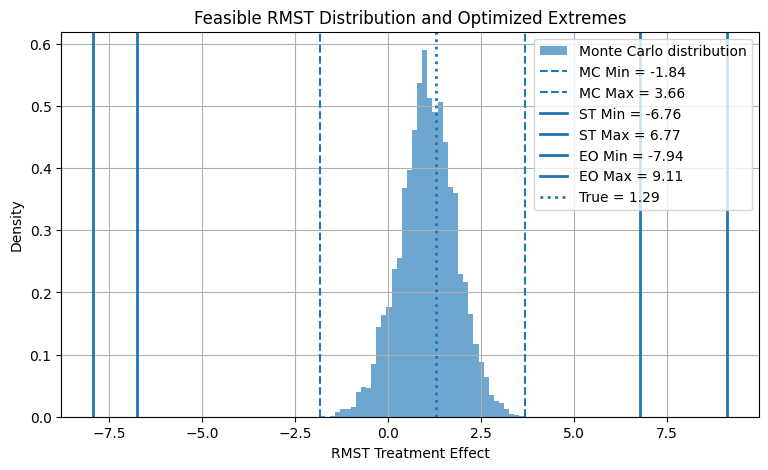

In [31]:
plt.figure(figsize=(9, 5))

plt.hist(mc_effects, bins=40, density=True, alpha=0.65, label="Monte Carlo distribution")

plt.axvline(mc_effects.min(), linestyle="--", label=f"MC Min = {mc_effects.min():.2f}")
plt.axvline(mc_effects.max(), linestyle="--", label=f"MC Max = {mc_effects.max():.2f}")

plt.axvline(st_min["best_effect"], linewidth=2, label=f"ST Min = {st_min['best_effect']:.2f}")
plt.axvline(st_max["best_effect"], linewidth=2, label=f"ST Max = {st_max['best_effect']:.2f}")

plt.axvline(eo_min_fast["best_effect"], linewidth=2, label=f"EO Min = {eo_min_fast['best_effect']:.2f}")
plt.axvline(eo_max_fast["best_effect"], linewidth=2, label=f"EO Max = {eo_max_fast['best_effect']:.2f}")

plt.axvline(true_effect, linestyle=":", linewidth=2, label=f"True = {true_effect:.2f}")

plt.xlabel("RMST Treatment Effect")
plt.ylabel("Density")
plt.title("Feasible RMST Distribution and Optimized Extremes")
plt.legend()
plt.show()

In [32]:
st_effects = np.concatenate([

    st_max["trace"]["effect"].values,

    st_min["trace"]["effect"].values

])

eo_effects = np.concatenate([

    eo_max_fast["trace"]["effect"].values,

    eo_min_fast["trace"]["effect"].values

])

comparison_dist = pd.DataFrame({
    "Method": ["MC", "ST", "EO"],
    "Mean": [
        np.mean(mc_effects),
        np.mean(st_effects),
        np.mean(eo_effects),
    ],
    "Q05": [
        np.quantile(mc_effects, 0.05),
        np.quantile(st_effects, 0.05),
        np.quantile(eo_effects, 0.05),
    ],
    "Median": [
        np.median(mc_effects),
        np.median(st_effects),
        np.median(eo_effects),
    ],
    "Q95": [
        np.quantile(mc_effects, 0.95),
        np.quantile(st_effects, 0.95),
        np.quantile(eo_effects, 0.95),
    ]
})

comparison_dist

,Method,Mean,Q05,Median,Q95
0,MC,1.060419,-0.238758,1.058822,2.294987
1,ST,0.862665,-4.390095,1.064210,5.505848
2,EO,0.732563,-7.323488,0.587866,8.669292


Monte Carlo reconstruction provides a reasonable characterization of the central feasible region. However, optimization-based search reveals substantially larger treatment-effect variability at the boundaries of the feasible assignment space. Consequently, uncertainty assessments based solely on random feasible sampling may underestimate the full range of treatment effects compatible with published aggregate evidence.

We want to check if these mins and maxes are feasible now:

In [33]:
def check_feasible(z, treatment, K1, K0):
    return {
        "total_ok": int(z.sum()) == K1 + K0,
        "treated_ok": int(z[treatment == 1].sum()) == K1,
        "control_ok": int(z[treatment == 0].sum()) == K0,
        "binary_ok": set(np.unique(z)).issubset({0, 1}),
        "total_positive": int(z.sum()),
        "treated_positive": int(z[treatment == 1].sum()),
        "control_positive": int(z[treatment == 0].sum()),
    }

In [34]:
treatment = observed_df["treatment"].values

pd.DataFrame([
    {"method": "ST max", **check_feasible(st_max["best_z"], treatment, K1, K0)},
    {"method": "ST min", **check_feasible(st_min["best_z"], treatment, K1, K0)},
    {"method": "EO max", **check_feasible(eo_max_fast["best_z"], treatment, K1, K0)},
    {"method": "EO min", **check_feasible(eo_min_fast["best_z"], treatment, K1, K0)},
])

,method,total_ok,treated_ok,control_ok,binary_ok,total_positive,treated_positive,control_positive
0,ST max,True,True,True,True,79,35,44
1,ST min,True,True,True,True,79,35,44
2,EO max,True,True,True,True,79,35,44
3,EO min,True,True,True,True,79,35,44


In [35]:
for name, result in {
    "ST max": st_max,
    "ST min": st_min,
    "EO max": eo_max_fast,
    "EO min": eo_min_fast,
}.items():
    recomputed = rmst_treatment_effect(
        observed_df,
        result["best_z"],
        config.tau
    )
    print(name, "stored:", round(result["best_effect"], 3), "recomputed:", round(recomputed, 3))

ST max stored: 6.774 recomputed: 6.774
ST min stored: -6.761 recomputed: -6.761
EO max stored: 9.109 recomputed: 9.109
EO min stored: -7.941 recomputed: -7.941


And for clinical plausibility: